# GreenSurge event reconstruction example tropical cyclone

## Read simulation dataset

In [49]:
import numpy as np
import xarray as xr

In [50]:
ds_GFD_info = xr.open_dataset(
    "outputs/GreenSurge_Cadiz_info.nc",
    decode_times=False,
)
ds_GFD_info

<xarray.Dataset> Size: 103kB
Dimensions:                            (element_computation_index: 3732,
                                        triangle_forcing_nodes: 3,
                                        node_forcing_index: 20,
                                        element_forcing_index: 24,
                                        wind_direction_index: 24,
                                        time_forcing_index: 4,
                                        node_cumputation_index: 2087)
Coordinates:
  * element_computation_index          (element_computation_index) int32 15kB ...
  * node_forcing_index                 (node_forcing_index) int32 80B 0 1 ... 19
  * element_forcing_index              (element_forcing_index) int32 96B 0 .....
  * wind_direction_index               (wind_direction_index) int32 96B 0 ... 23
  * time_forcing_index                 (time_forcing_index) float64 32B 0.0 ....
  * node_cumputation_index             (node_cumputation_index) int32 8kB 0 ....
    node_computation_longitude         (node_cumputation_index) float64 17kB ...
    node_computation_latitude          (node_cumputation_index) float64 17kB ...
    triangle_nodes                     (triangle_forcing_nodes) int32 12B ...
Dimensions without coordinates: triangle_forcing_nodes
Data variables: (12/14)
    triangle_computation_connectivity  (element_computation_index, triangle_forcing_nodes) int32 45kB ...
    node_forcing_longitude             (node_forcing_index) float64 160B ...
    node_forcing_latitude              (node_forcing_index) float64 160B ...
    triangle_forcing_connectivity      (element_forcing_index, triangle_forcing_nodes) int32 288B ...
    wind_directions                    (wind_direction_index) int32 96B ...
    total_elements                     int32 4B ...
    ...                                 ...
    wind_speed                         int32 4B ...
    location_name                      object 8B ...
    eddy_viscosity                     int32 4B ...
    chezy_coefficient                  int32 4B ...
    reference_date                     object 8B ...
    forcing_time_step                  int32 4B ...
Attributes:
    title:        GreenSurge Simulation Input Dataset
    institution:  GeoOcean
    model:        GreenSurge
    created:      2026-02-17 16:18:50

In [27]:
p_tracks = "https://geoocean.sci.unican.es/thredds/dodsC/geoceanData/GEOOCEAN/IBTrACS.ALL.v04r00.nc"
xds_tcs = xr.open_dataset(p_tracks)

name_tc, year_tc = "VINCE", 2005


itc = np.where(
    (xds_tcs["name"].values.astype("str") == name_tc)
    & (xds_tcs.isel(date_time=0).time.dt.year.values == year_tc)
)[0]
storm = xds_tcs.isel(storm=itc).squeeze().load()
storm

<xarray.Dataset> Size: 556kB
Dimensions:           (date_time: 360, quadrant: 4)
Coordinates:
    time              (date_time) datetime64[ns] 3kB 2005-10-08T06:00:00.0000...
    lat               (date_time) float32 1kB 32.9 32.95 33.0 ... nan nan nan
    lon               (date_time) float32 1kB -20.6 -20.44 -20.3 ... nan nan nan
Dimensions without coordinates: date_time, quadrant
Data variables: (12/147)
    numobs            float32 4B 27.0
    sid               |S64 64B b'2005281N33339'
    season            float32 4B 2.005e+03
    number            int16 2B 93
    basin             (date_time) |S64 23kB b'NA' b'NA' b'NA' ... b'' b'' b''
    subbasin          (date_time) |S64 23kB b'NA' b'NA' b'NA' ... b'' b'' b''
    ...                ...
    reunion_gust      (date_time) float32 1kB nan nan nan nan ... nan nan nan
    reunion_gust_per  (date_time) float32 1kB nan nan nan nan ... nan nan nan
    usa_seahgt        (date_time) float32 1kB nan nan nan nan ... nan nan nan
    usa_searad        (date_time, quadrant) float32 6kB nan nan nan ... nan nan
    storm_speed       (date_time) float32 1kB 3.0 3.0 2.0 2.0 ... nan nan nan
    storm_dir         (date_time) float32 1kB 69.0 68.0 65.0 ... nan nan nan
Attributes: (12/52)
    title:                      IBTrACS - International Best Track Archive fo...
    summary:                    The intent of the IBTrACS project is to overc...
    source:                     The original data are tropical cyclone positi...
    Conventions:                ACDD-1.3
    Conventions_note:           Data are nearly CF-1.7 compliant. The sole is...
    product_version:            v04r00
    ...                         ...
    cdm_data_type:              Trajectory
    comment:                    The tracks of TCs generally look like a traje...
    nco_openmp_thread_number:   1
    NCO:                        4.4.3
    DODS.strlen:                2
    DODS.dimName:               char2

In [29]:
from bluemath_tk.tcs.tracks import (
    historic_track_interpolation,
    historic_track_preprocessing,
)

centerID = "USA"
df_TC_hist = historic_track_preprocessing(xds=storm, center=centerID)
storm_track, time_input = historic_track_interpolation(
    df=df_TC_hist, dt_comp=ds_GFD_info.time_step_hours.values * 60
)
storm_track

,center,basin,dist2land,lon,lat,move,vf,vfx,vfy,pn,p0,vmax,rmw,vmaxfill,rmwfill
2005-10-08 06:00:00,USA,NA,628.0,339.399996,32.900000,249.303558,2.832160,2.649390,1.000933,1013,1001.000000,40.000000,59.125572,False,True
2005-10-08 07:00:00,USA,NA,628.0,339.452446,32.916702,249.303558,2.832160,2.649390,1.000933,1013,1000.666667,40.666667,58.635527,False,True
2005-10-08 08:00:00,USA,NA,628.0,339.504916,32.933383,249.303558,2.832160,2.649390,1.000933,1013,1000.333333,41.333333,58.145482,False,True
2005-10-08 09:00:00,USA,NA,626.0,339.557472,32.950052,247.367203,2.596576,2.396614,0.999224,1013,1000.000000,42.000000,57.655437,False,True
2005-10-08 10:00:00,USA,NA,626.0,339.604945,32.966728,247.367203,2.596576,2.396614,0.999224,1013,1000.000000,43.000000,56.935422,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-10-11 07:00:00,USA,NA,45.0,352.100384,36.864484,242.824570,21.670415,19.278275,9.897223,1013,1002.000000,30.000000,70.101153,False,True
2005-10-11 08:00:00,USA,NA,45.0,352.502463,37.027610,242.824570,21.670415,19.278275,9.897223,1013,1002.000000,30.000000,80.202306,False,True
2005-10-11 09:00:00,USA,NA,0.0,352.900001,37.199999,240.541412,20.163150,17.556285,9.916123,1013,1002.000000,30.000000,NaN,False,True
2005-10-11 10:00:00,USA,NA,0.0,353.267012,37.364889,240.541412,20.163150,17.556285,9.916123,1013,1002.333333,30.000000,NaN,False,True


## Generate a regular grid for the vortex model and apply the vortex model to the storm track

In [30]:
from bluemath_tk.additive.greensurge import get_regular_grid
from bluemath_tk.tcs.vortex import vortex_model_grid

lon_grid, lat_grid = get_regular_grid(
    node_computation_longitude=ds_GFD_info.node_computation_longitude.values,
    node_computation_latitude=ds_GFD_info.node_computation_latitude.values,
    node_computation_elements=ds_GFD_info.triangle_computation_connectivity.values,
    factor=10,
)

xds_vortex_GS = vortex_model_grid(
    storm_track=storm_track,
    cg_lon=lon_grid,
    cg_lat=lat_grid,
    coords_mode="SPHERICAL",
)
xds_vortex_GS

<xarray.Dataset> Size: 21MB
Dimensions:  (lat: 128, lon: 88, time: 78)
Coordinates:
  * lat      (lat) float64 1kB 36.12 36.12 36.13 36.14 ... 36.96 36.96 36.97
  * lon      (lon) float64 704B -6.829 -6.819 -6.809 ... -6.005 -5.995 -5.985
  * time     (time) datetime64[ns] 624B 2005-10-08T06:00:00 ... 2005-10-11T11...
Data variables:
    W        (lat, lon, time) float64 7MB 0.4903 0.4955 0.5001 ... 0.0 0.0 0.0
    Dir      (lat, lon, time) float64 7MB 169.8 169.8 169.8 ... 0.0 0.0 0.0
    p        (lat, lon, time) float64 7MB 1.012e+05 1.012e+05 ... 0.0 0.0

In [61]:
xds_vortex_GS["W"] = xds_vortex_GS.W * 10

In [62]:
dynamic_path = "outputs/Dynamic_CASE/"

In [64]:
from datetime import datetime

reference_datetime = datetime.strptime(
    str(xds_vortex_GS.time.values[0]).split(".")[0].replace("T", " "),
    "%Y-%m-%d %H:%M:%S",
)
simulation_end_datetime = datetime.strptime(
    str(xds_vortex_GS.time.values[-1]).split(".")[0].replace("T", " "),
    "%Y-%m-%d %H:%M:%S",
)

drag_coefficients = [0.00063, 0.00723, 0.00723]
velocity_thresholds = [0, 100, 100]
wind_equilibrium_code = 2

metamodel_parameters = {
    "vortex": [xds_vortex_GS],
}

fixed_parameters = {
    "MapInterval": 3600 * ds_GFD_info.time_step_hours.values,
    "RefDate": reference_datetime.strftime("%Y%m%d"),
    "StartDateTime": reference_datetime.strftime("%Y%m%d%H%M%S"),
    "StopDateTime": simulation_end_datetime.strftime("%Y%m%d%H%M%S"),
    "CDa": drag_coefficients[0],
    "CDb": drag_coefficients[1],
    "CDc": drag_coefficients[2],
    "VCDa": velocity_thresholds[0],
    "VCDb": velocity_thresholds[1],
    "VCDc": velocity_thresholds[2],
    "Wind_eq": wind_equilibrium_code,
    "eddy": ds_GFD_info.eddy_viscosity.values,
    "chezy": ds_GFD_info.chezy_coefficient.values,
    "W2Map": 1,
    "dt_forz": ds_GFD_info.forcing_time_step.values,
    "SetupType": "Dynamic",
    "forcing_ds": "forcing.nc",
    "mesh_path": f"templates/mesh_{ds_GFD_info.location_name.values}_net.nc",
    "NetFile": f"mesh_{ds_GFD_info.location_name.values}_net.nc",
}

from bluemath_tk.wrappers.delft3d.delft3d_wrapper import GreenSurgeModelWrapper

delft3d_wrapper = GreenSurgeModelWrapper(
    templates_dir="templates",
    metamodel_parameters=metamodel_parameters,
    fixed_parameters=fixed_parameters,
    output_dir=dynamic_path,
)

delft3d_wrapper.build_cases()

2026-02-17 17:37:56,442 - GreenSurgeModelWrapper - WARNING - Parameter vortex is not in the default_parameters


In [65]:
delft3d_wrapper.run_cases(launcher="dimr dimr_config.xml")

2026-02-17 17:38:09,340 - GreenSurgeModelWrapper - ERROR - Error running command: dimr dimr_config.xml
2026-02-17 17:38:09,342 - GreenSurgeModelWrapper - ERROR - Error: Command 'dimr dimr_config.xml' died with <Signals.SIGSEGV: 11>.


In [66]:
ds_WL_dynamic_WindSetUp = xr.open_dataset(
    f"{dynamic_path}/0000/dflowfmoutput/GreenSurge_GFDcase_map.nc"
)
ds_WL_dynamic_WindSetUp

<xarray.Dataset> Size: 4MB
Dimensions:             (mesh2d_nNodes: 2087, mesh2d_nEdges: 5818, Two: 2,
                         mesh2d_nFaces: 3732, mesh2d_nMax_face_nodes: 3, time: 8)
Coordinates:
  * time                (time) datetime64[ns] 64B 2005-10-08T06:00:00 ... 200...
    mesh2d_node_x       (mesh2d_nNodes) float64 17kB ...
    mesh2d_node_y       (mesh2d_nNodes) float64 17kB ...
    mesh2d_edge_x       (mesh2d_nEdges) float64 47kB ...
    mesh2d_edge_y       (mesh2d_nEdges) float64 47kB ...
    mesh2d_face_x       (mesh2d_nFaces) float64 30kB ...
    mesh2d_face_y       (mesh2d_nFaces) float64 30kB ...
Dimensions without coordinates: mesh2d_nNodes, mesh2d_nEdges, Two,
                                mesh2d_nFaces, mesh2d_nMax_face_nodes
Data variables: (12/24)
    wgs84               int32 4B ...
    mesh2d              int32 4B ...
    mesh2d_node_z       (mesh2d_nNodes) float64 17kB ...
    mesh2d_edge_nodes   (mesh2d_nEdges, Two) int32 47kB ...
    mesh2d_face_nodes   (mesh2d_nFaces, mesh2d_nMax_face_nodes) float64 90kB ...
    mesh2d_edge_faces   (mesh2d_nEdges, Two) float64 93kB ...
    ...                  ...
    mesh2d_ucy          (time, mesh2d_nFaces) float64 239kB ...
    mesh2d_ucmag        (time, mesh2d_nFaces) float64 239kB ...
    mesh2d_windx        (time, mesh2d_nFaces) float64 239kB ...
    mesh2d_windy        (time, mesh2d_nFaces) float64 239kB ...
    mesh2d_windxu       (time, mesh2d_nEdges) float64 372kB ...
    mesh2d_windyu       (time, mesh2d_nEdges) float64 372kB ...
Attributes: (12/18)
    institution:               Deltares
    references:                https://www.deltares.nl
    source:                    D-Flow FM 1.2.184.Unknown. Model:
    history:                   Created on 2026-02-17T17:38:03-0000, D-Flow FM
    date_created:              2026-02-17T17:38:03-0000
    date_modified:             2026-02-17T17:38:03-0000
    ...                        ...
    geospatial_lon_max:        -5.98973254260087
    geospatial_lon_units:      degrees_east
    time_coverage_start:       2005-10-08T06:00:00+00:00
    time_coverage_end:         2005-10-11T11:00:00+00:00
    time_coverage_duration:    P0000-00-03T05:00:00
    time_coverage_resolution:  P0000-00-00T01:00:00

In [67]:
from bluemath_tk.additive.greensurge import GS_wind_partition_tri

xds_vortex_interp = GS_wind_partition_tri(
    ds_GFD_info=ds_GFD_info, xds_vortex=xds_vortex_GS
)
xds_vortex_interp

<xarray.Dataset> Size: 46kB
Dimensions:  (element: 24, time: 78)
Coordinates:
  * element  (element) int32 96B 0 1 2 3 4 5 6 7 8 ... 16 17 18 19 20 21 22 23
  * time     (time) datetime64[ns] 624B 2005-10-08T06:00:00 ... 2005-10-11T11...
Data variables:
    Dir      (element, time) float64 15kB 169.0 169.0 169.0 ... 180.0 180.0
    W        (element, time) float64 15kB 4.702 4.751 4.793 ... 0.0 0.0 0.0
    p        (element, time) float64 15kB 1.012e+05 1.012e+05 ... 0.0 0.0

In [68]:
figsize = (10, 5)

instant = np.round(np.arange(2 / 3, 1, 1 / 12) * len(xds_vortex_interp.time)).astype(
    int
)[:-1]
instant

array([52, 58, 65, 72])

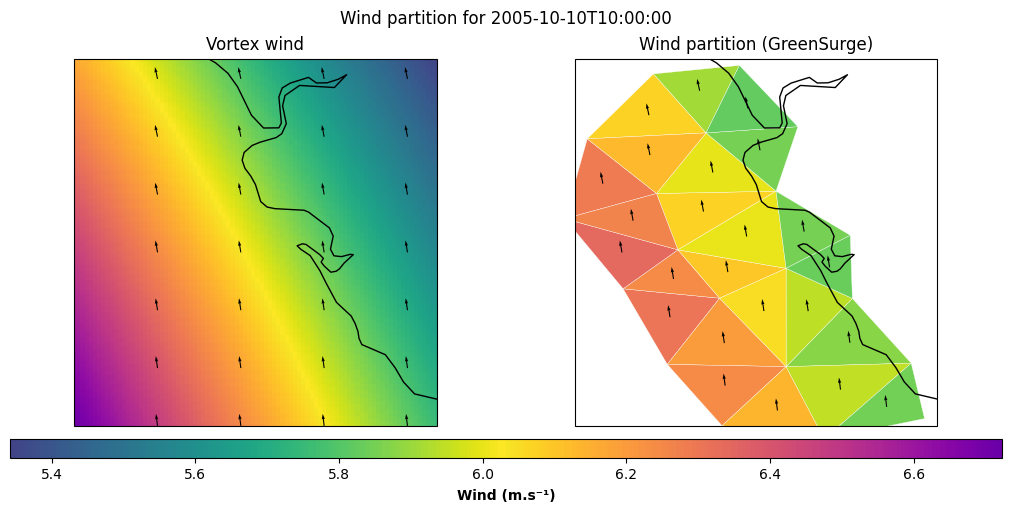

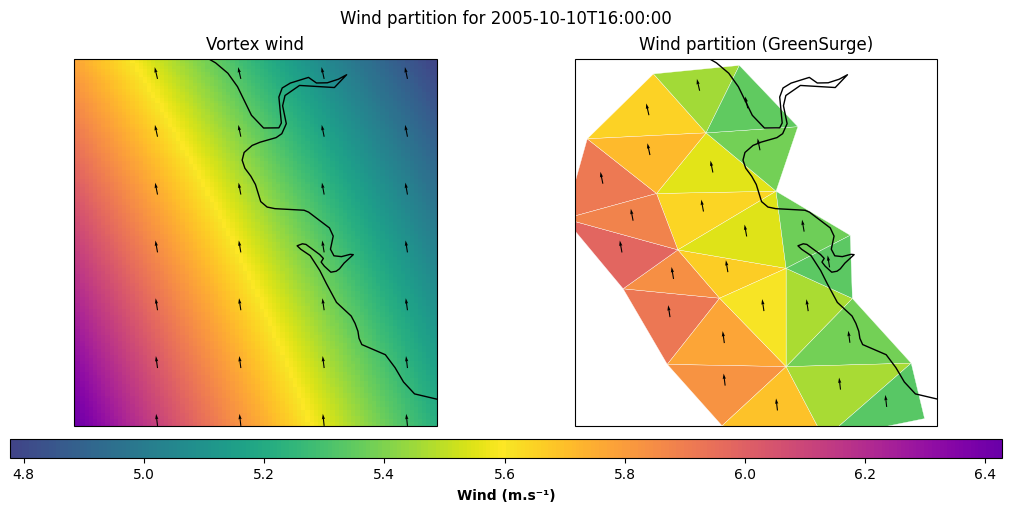

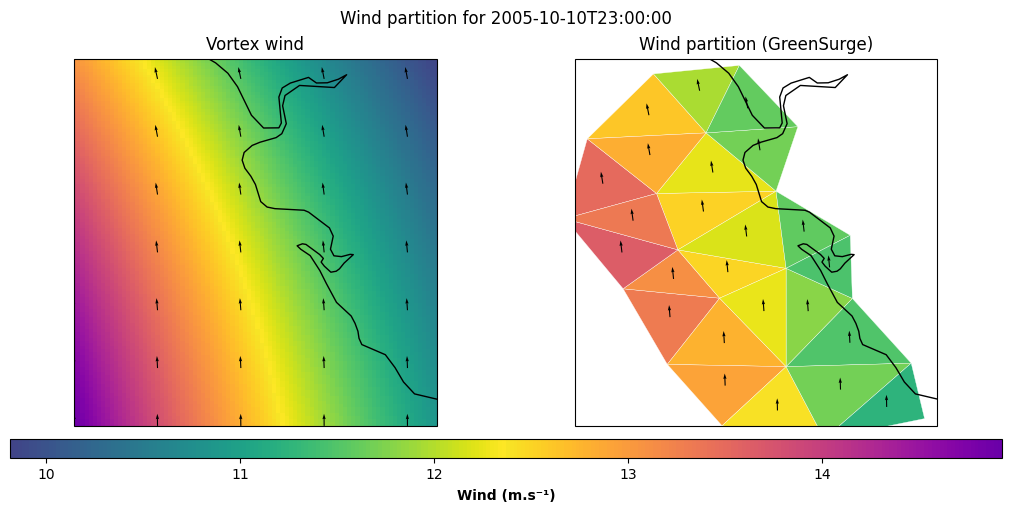

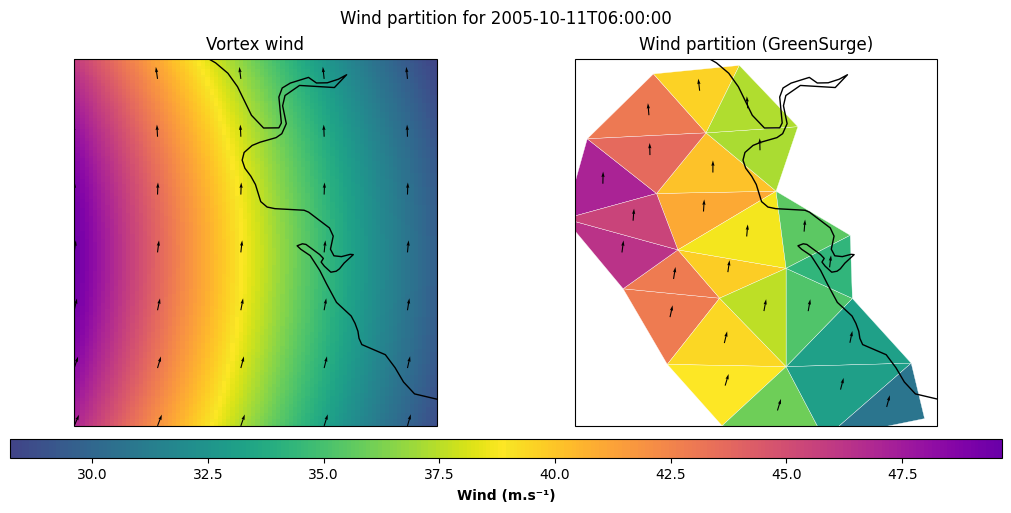

In [69]:
from bluemath_tk.additive.greensurge import plot_GS_input_wind_partition

for i in instant:
    plot_GS_input_wind_partition(
        xds_vortex_GS=xds_vortex_GS,
        xds_vortex_interp=xds_vortex_interp,
        ds_GFD_info=ds_GFD_info,
        i_time=i,
        figsize=figsize,
    )

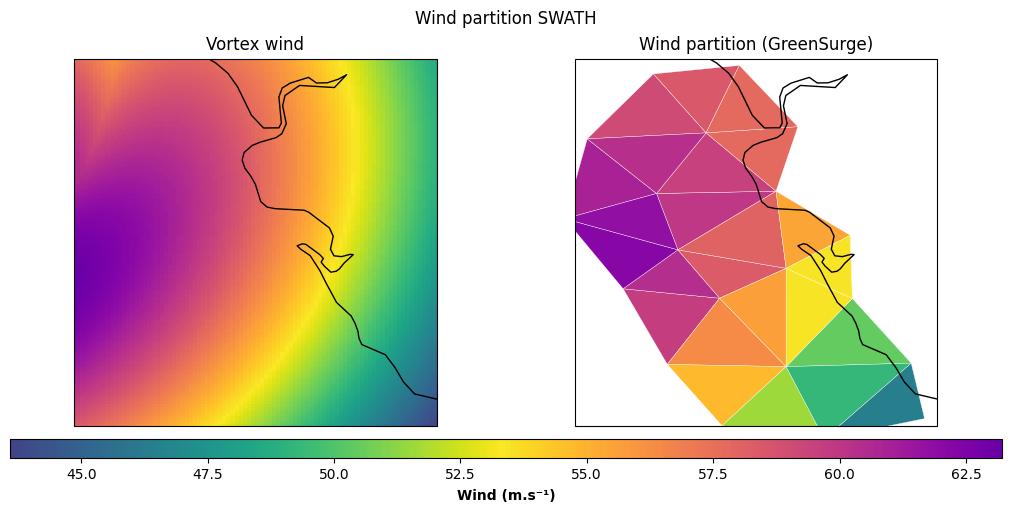

In [70]:
plot_GS_input_wind_partition(
    xds_vortex_GS=xds_vortex_GS,
    xds_vortex_interp=xds_vortex_interp,
    ds_GFD_info=ds_GFD_info,
    SWATH=True,
    figsize=figsize,
)

In [71]:
from bluemath_tk.additive.greensurge import actualize_grid_info

greensurge_dataset = "outputs/GreenSurge_CASES"

ds_GFD_info_update = actualize_grid_info(
    f"{greensurge_dataset}/GF_T_0_D_0/dflowfmoutput/GreenSurge_GFDcase_map.nc",
    ds_GFD_info,
)
ds_GFD_info_update

<xarray.Dataset> Size: 103kB
Dimensions:                            (element_computation_index: 3732,
                                        triangle_forcing_nodes: 3,
                                        node_forcing_index: 20,
                                        element_forcing_index: 24,
                                        wind_direction_index: 24,
                                        time_forcing_index: 4,
                                        node_cumputation_index: 2087)
Coordinates:
  * element_computation_index          (element_computation_index) int32 15kB ...
  * node_forcing_index                 (node_forcing_index) int32 80B 0 1 ... 19
  * element_forcing_index              (element_forcing_index) int32 96B 0 .....
  * wind_direction_index               (wind_direction_index) int32 96B 0 ... 23
  * time_forcing_index                 (time_forcing_index) float64 32B 0.0 ....
  * node_cumputation_index             (node_cumputation_index) int32 8kB 0 ....
    node_computation_longitude         (node_cumputation_index) float64 17kB ...
    node_computation_latitude          (node_cumputation_index) float64 17kB ...
    triangle_nodes                     (triangle_forcing_nodes) int32 12B ...
Dimensions without coordinates: triangle_forcing_nodes
Data variables: (12/14)
    triangle_computation_connectivity  (element_computation_index, triangle_forcing_nodes) int32 45kB ...
    node_forcing_longitude             (node_forcing_index) float64 160B -6.8...
    node_forcing_latitude              (node_forcing_index) float64 160B 36.6...
    triangle_forcing_connectivity      (element_forcing_index, triangle_forcing_nodes) int32 288B ...
    wind_directions                    (wind_direction_index) int32 96B 0 ......
    total_elements                     int32 4B ...
    ...                                 ...
    wind_speed                         int32 4B 5
    location_name                      object 8B 'Cadiz'
    eddy_viscosity                     int32 4B 10
    chezy_coefficient                  int32 4B 70
    reference_date                     object 8B ...
    forcing_time_step                  int32 4B 1
Attributes:
    title:        GreenSurge Simulation Input Dataset
    institution:  GeoOcean
    model:        GreenSurge
    created:      2026-02-17 16:18:50

In [72]:
from bluemath_tk.additive.greensurge import greensurge_wind_setup_reconstruction_raw

ds_wind_setup = greensurge_wind_setup_reconstruction_raw(
    greensurge_dataset=greensurge_dataset,
    ds_GFD_info_update=ds_GFD_info_update,
    xds_vortex_interp=xds_vortex_interp,
)
ds_wind_setup

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/GreenSurge_CASES/GF_T_0_D_0/dflowfmoutput/GreenSurge_GFDcase_map.raw'

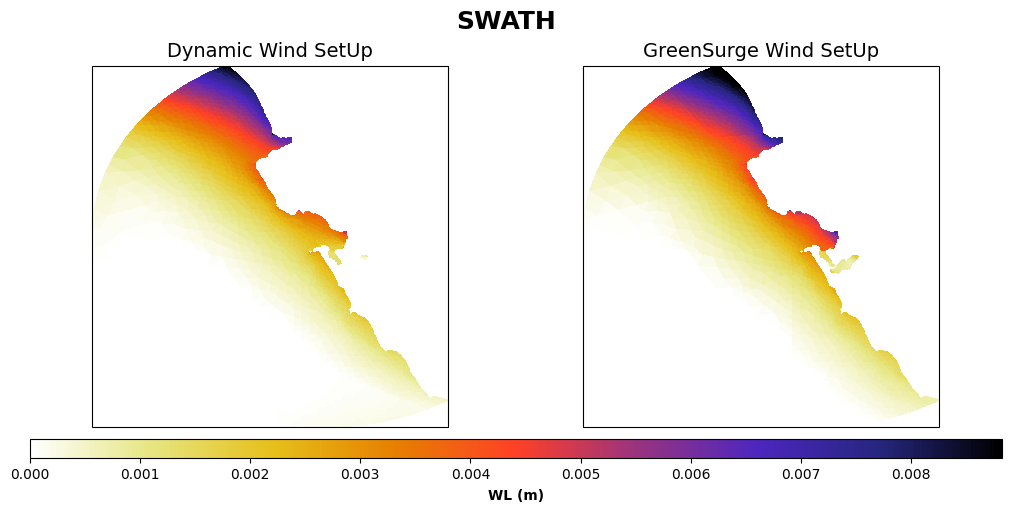

In [ ]:
from bluemath_tk.additive.greensurge import plot_GS_vs_dynamic_windsetup_swath

plot_GS_vs_dynamic_windsetup_swath(
    ds_WL_GS_WindSetUp=ds_wind_setup,
    ds_WL_dynamic_WindSetUp=ds_WL_dynamic_WindSetUp,
    ds_gfd_metadata=ds_GFD_info_update,
    vmin=0,
    vmax=np.nanmax(ds_WL_dynamic_WindSetUp.mesh2d_s1.values),
    figsize=figsize,
);

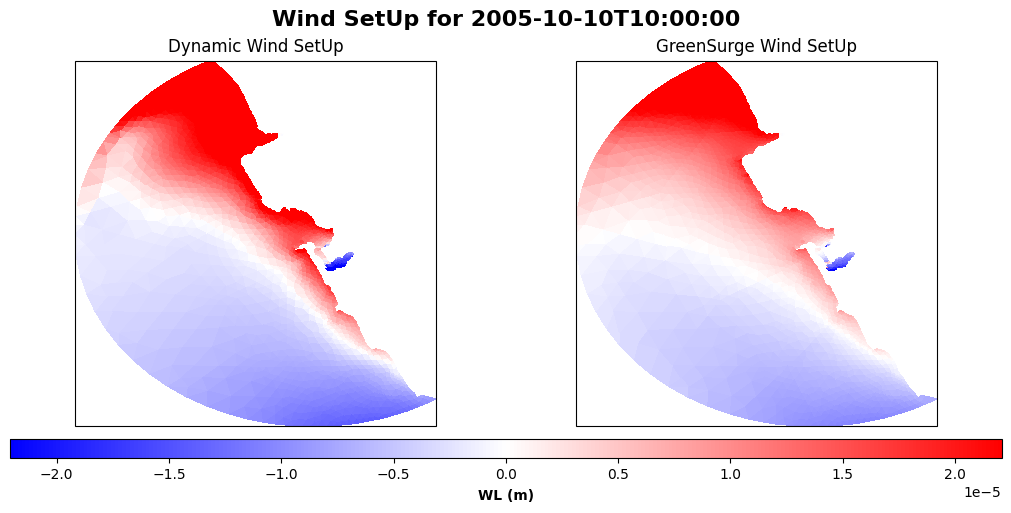

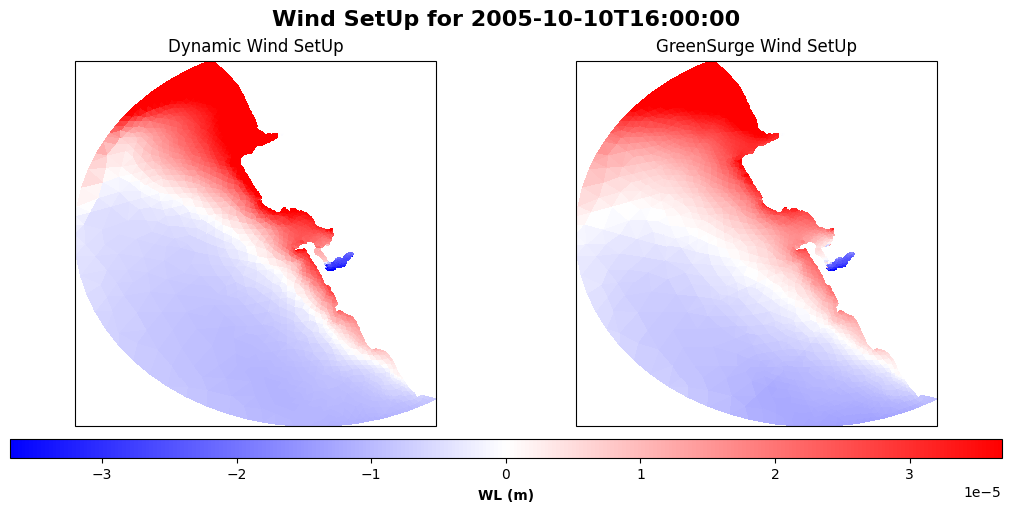

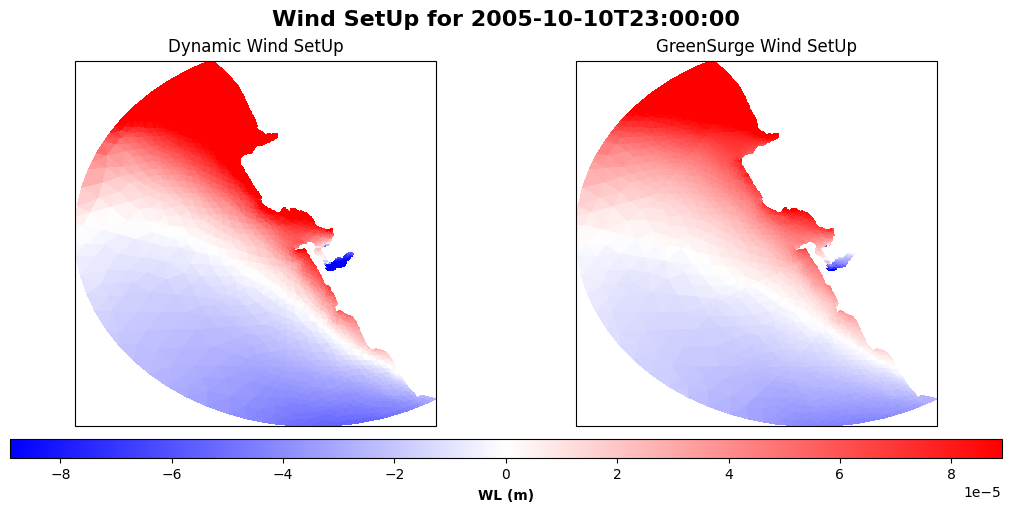

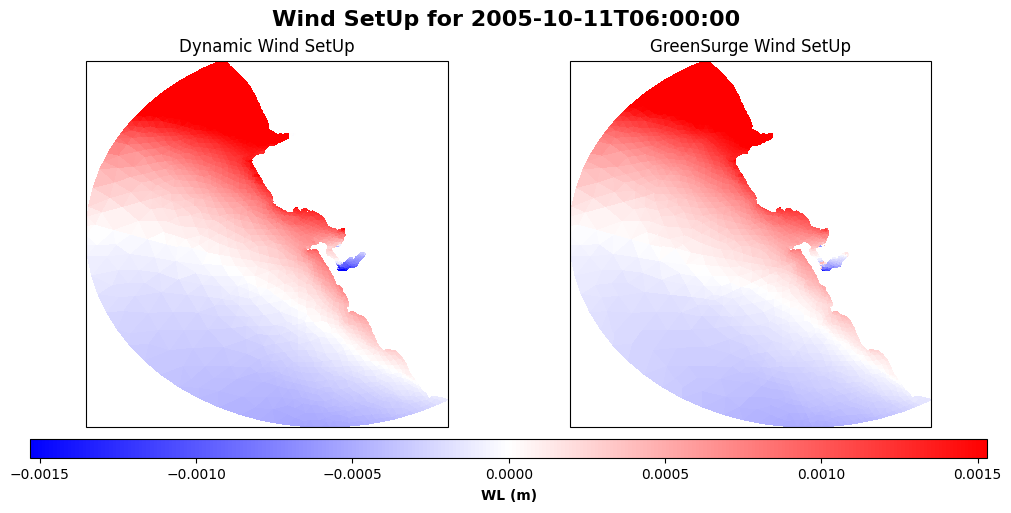

In [ ]:
from bluemath_tk.additive.greensurge import plot_GS_vs_dynamic_windsetup

for i in instant:
    plot_GS_vs_dynamic_windsetup(
        ds_WL_GS_WindSetUp=ds_wind_setup,
        ds_WL_dynamic_WindSetUp=ds_WL_dynamic_WindSetUp,
        ds_gfd_metadata=ds_GFD_info_update,
        time=ds_WL_dynamic_WindSetUp.time[i].values,
        figsize=figsize,
    )